In [1]:
from langgraph.prebuilt import create_react_agent
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict, Annotated, List, Dict, Any
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field, field_validator
from IPython.display import Image, display
from dotenv import load_dotenv
import gradio as gr
import fitz
import os

load_dotenv(override=True)

c:\Users\PratikTalaviya\Crest-Projects\Document-Processing-Agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:

GEMINI_BASE_URL = os.getenv("GEMINI_BASE_URL")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

model = init_chat_model("google_genai:gemini-2.5-flash")

In [3]:
class State(TypedDict):
    """
    The state for our LangGraph agent.
    """
    # documents: List[str] # List of document identifiers
    chat_history: Annotated[list[dict[str, str]], add_messages]
    query: str
    response: str
    document: Dict[str, str]
    extracted_text: Dict[str, str]
    summary: str
    question_list: List[str]
    s3Uri: Dict[str, str]
    result_url: Dict[str, str]
    bda_result: Dict[str, str]
    messages: Annotated[list, add_messages]
    # is_inter_document_query: bool

In [4]:
class State(TypedDict):
    """
    The state for our LangGraph agent.
    """
    # documents: List[str] # List of document identifiers
    chat_history: Annotated[list[dict[str, str]], add_messages]
    query: str
    response: str
    document: Dict[str, str]
    extracted_text: Dict[str, str]
    summary: str
    question_list: List[str]
    s3Uri: Dict[str, str]
    result_url: Dict[str, str]
    bda_result: Dict[str, str]
    messages: Annotated[list, add_messages]
    # is_inter_document_query: bool

In [5]:
import base64
import fitz  # PyMuPDF
import boto3
from io import BytesIO
import logging
from urllib.parse import urlparse
from langchain_core.tools import tool
import json
import uuid
# from langgraph.checkpoint import get_state

logger = logging.getLogger()
logger.setLevel(logging.INFO)

@tool
def extract_image_from_pdf_bbox(filename: str, geometry: Dict[str, Any]):
    """
    Tool to crop an image from a PDF stored in S3 using bounding box details
    and upload the cropped image back to S3.

    Args:
        filename (str): Name of the PDF file (must exist in state["s3Uri"])
        geometry (dict): {
            "boundingBox": {
                "left": float,
                "top": float,
                "width": float,
                "height": float
            },
            "page": int
        }
    Returns:
        dict: {
            "success": bool,
            "s3Url": "<uploaded_image_s3_url>"
        }
    """

    graph_state = graph.get_state(config)
    state = dict(graph_state.values)
    
    try:
        if not filename or not geometry:
            return {"error": "Missing filename or geometry"}

        bbox = geometry.get("boundingBox")
        if not bbox:
            return {"error": "Missing boundingBox in geometry"}

        # ✅ Lookup S3 URI from state (hidden from LLM)
        if state is None:
            return {"error": "State not provided to tool"}

        s3_uri = state["s3Uri"].get(filename)
        if not s3_uri:
            return {"error": f"No S3 URI found in state for '{filename}'"}

        parsed = urlparse(s3_uri)
        bucket = parsed.netloc
        key = parsed.path.lstrip("/")

        # Download PDF from S3
        s3 = boto3.client("s3")
        obj = s3.get_object(Bucket=bucket, Key=key)
        pdf_bytes = obj["Body"].read()

        # Open PDF with PyMuPDF
        doc = fitz.open(stream=BytesIO(pdf_bytes), filetype="pdf")
        page_num = int(geometry.get("page", 1)) - 1  # 0-indexed
        if page_num >= len(doc):
            return {"error": f"Invalid page number: {page_num + 1}"}

        page = doc.load_page(page_num)
        page_width, page_height = page.rect.width, page.rect.height

        # Normalized bbox -> absolute coordinates
        x0 = bbox["left"] * page_width
        y0 = bbox["top"] * page_height
        x1 = x0 + (bbox["width"] * page_width)
        y1 = y0 + (bbox["height"] * page_height)

        # Apply padding (10%)
        width = x1 - x0
        height = y1 - y0
        padding_x = width * 0.1
        padding_y = height * 0.1

        x0 = max(0, x0 - padding_x)
        y0 = max(0, y0 - padding_y)
        x1 = min(page_width, x1 + padding_x)
        y1 = min(page_height, y1 + padding_y)

        rect = fitz.Rect(x0, y0, x1, y1)
        matrix = fitz.Matrix(2.0, 2.0)  # upscale for clarity
        pix = page.get_pixmap(matrix=matrix, clip=rect)
        image_bytes = pix.tobytes("png")

        doc.close()

        output_bucket = bucket  # default: same as source PDF
        # Choose output bucket
        # if not outputS3Bucket:
        #     output_bucket = bucket  # default: same as source PDF
        # else:
        #     output_bucket = outputS3Bucket
        image_key = f"cropped_images/{uuid.uuid4().hex}.png"

        # Upload cropped image
        s3.put_object(
            Bucket=output_bucket,
            Key=image_key,
            Body=image_bytes,
            ContentType="image/png"
        )

        s3_url = f"https://{output_bucket}.s3.amazonaws.com/{image_key}"

        return {"success": True, "s3Url": s3_url}

    except Exception as e:
        logger.error(f"Cropping/upload error: {str(e)}")
        return {"error": str(e)}

In [ ]:
# class structureOutput(BaseModel):
#     text_message: str = Field(
#         description="Text message to user from llm"
#     )
#     image_urls: Dict[str, str] = Field(
#         default_factory=dict,
#         description="Dictionary with key as name of the image extracted and values as S3 URLs of cropped image if generated using tool by llm else empty"
#     )
#     @field_validator("image_urls", mode="before")
#     def parse_json_dict(cls, v):
#         if isinstance(v, str):
#             try:
#                 return json.loads(v)
#             except Exception:
#                 raise ValueError("image_urls must be a valid JSON object")
#         return v

agent = create_react_agent(
    model,
    tools=[extract_image_from_pdf_bbox],
    # response_format=structureOutput,
)

# def update_message(messages, msg_id, new_content):
#     updated_messages = []
#     for m in messages:
#         if isinstance(m, HumanMessage) and getattr(m, "id", None) == msg_id:
#             # Replace with updated human message
#             updated_messages.append(HumanMessage(content=new_content, id=None))
#         elif isinstance(m, ToolMessage):
#             # Skip tool messages completely (removes them)
#             continue
#         else:
#             updated_messages.append(m)
#     return updated_messages

def update_message(messages, msg_id, new_content):
    pruned = []
    skip_tool_section = False
    
    for i, m in enumerate(messages):

        if isinstance(m, HumanMessage) and m.id == msg_id:
            pruned.append(HumanMessage(content=new_content, id=None))

        elif isinstance(m, AIMessage) and m.tool_calls:
            # Skip the AI tool call
            skip_tool_section = True
            continue

        elif isinstance(m, ToolMessage) and skip_tool_section:
            # Skip the tool response
            continue

        else:
            # End of a tool interaction section, keep normal messages
            skip_tool_section = False
            pruned.append(m)

    return pruned

def agent_node(state : State):
    print("---NODE: AGENT---")
    messages = state["messages"]
    bda_context = state["bda_result"]
    query = state["query"] or ""

    if not query.strip():
        return {
            "response": [{"text_message": "Your query was empty. Can you clarify?", "image_urls": []}],
        }
    prompt = f"""
    You are a helpful assistant. 
    - Summarize tool outputs for the user.
    - If a tool returns an Image URL, include it.
    - For signature-related queries only, always crop the signature and show the cropped image URL also provide context of the signature.
    - For other images if asked then only crop them and use details from context for cropping do not generate 
    - Never give empty responses. If unclear, ask ONE clarifying question.
    - If multiple bounding box found for same field merge it into single one.
    Context: {bda_context}
    User query: {query}
    """
    conversation = messages + [HumanMessage(content=prompt,id="last-human-message")]
    # Call agent
    agent_response = agent.invoke({"messages": conversation})

    response = agent_response["messages"]
    new_response = update_message(response, "last-human-message", query)

    # print(agent_response)
    # response_list = [agent_response["structured_response"].model_dump()]
    # print(response_list)

    # # ✅ Ensure we return a dict with "messages"
    # return {"messages": new_response, "response": response_list}
    return {"messages": new_response}


In [7]:
class summaryDocuments(BaseModel):
    summary: str = Field(
        description="Summary of all the documents upload by the user"
    )
    questions: List[str] = Field(
        description="List of the Question user can directly ask only three questions regarding documents passed"
    )

def summarize_documents(state: State):
    print("---NODE: SUMMARIZATION OF DOUCMENTS---")
    extracted_text = state["extracted_text"]
    summarization_prompt = f"""
    You have been given data of the documents which will be used to answer user question regaring the documents and information filled in that documents. And user can ask inter-document question as well.
    Here is the Text of all documents :
    {extracted_text}
    Based on the Extracted Text from the Documents it can be single and multiple you have to create a short summary of all the document, and provide three question user can directly asked regarding those documents if possible regarding the fields filled in the documents. 
    """
    response = model.with_structured_output(summaryDocuments).invoke(summarization_prompt)

    summary = response.summary
    questions = response.questions

    state["summary"] = summary
    state["question_list"] = questions

    return state



In [8]:
# Upload Documents to S3
import boto3
from botocore.exceptions import ClientError
import uuid

def s3_upload_node(state: State):
    """
    Node to upload uploaded PDF files (bytes) to an S3 bucket.
    Returns state with S3 URIs for each file.
    """
    print("---NODE: S3 UPLOAD---")

    file_bytes_dict = state.get("document")
    if not file_bytes_dict:
        raise ValueError("No file bytes found in state")

    bucket_name = "document-processing-agent-pratik"   
    s3_client = boto3.client("s3")

    uploaded_files = {}

    for file_name, file_bytes in file_bytes_dict.items():
        try:
            # Generate unique key for each file
            unique_key = f"uploads/{uuid.uuid4()}/{file_name}"

            # Upload to S3
            s3_client.put_object(
                Bucket=bucket_name,
                Key=unique_key,
                Body=file_bytes,
                ContentType="application/pdf"
            )

            # Construct S3 URI
            s3_uri = f"s3://{bucket_name}/{unique_key}"
            uploaded_files[file_name] = s3_uri
            print(f"Uploaded {file_name} -> {s3_uri}")

        except ClientError as e:
            print(f"Error uploading {file_name}: {e}")
            raise

    # Update state with S3 URIs
    return {
        "s3Uri": uploaded_files,
        "document": None
    }



In [9]:
# Node for BDA processing of documents
import boto3
import time
import uuid
from botocore.exceptions import ClientError

def bda_process_node(state: dict):
    """
    Node to process documents in S3 via Bedrock Data Automation.
    Uses a previously created project ARN (or creates one),
    invokes processing for each file, polls for completion, and
    records output URIs in state.
    Requires:
      - state["s3_documents"]: dict {file_name: s3_uri}
      - state["bda_project_arn"]: optional existing project ARN
      - AWS credentials and permissions for Bedrock and S3
    Returns:
      - state["bda_results"]: {file_name: job_output_s3_uri}
    """
    print("---NODE: BDA DOCUMENT PROCESSING---")

    s3_docs = state.get("s3Uri")
    if not s3_docs:
        raise ValueError("No S3 documents found in state")

    client = boto3.client("bedrock-data-automation-runtime")
    project_arn = "arn:aws:bedrock:us-east-1:970547377074:data-automation-project/570db58af251"

    # Optionally create a project if missing
    # if not project_arn:
    #     print("Creating BDA project...")
    #     project_name = f"doc-processing-{uuid.uuid4()}"
    #     response = client.create_data_automation_project(
    #         projectName=project_name,
    #         projectDescription="Auto-generated project for document processing",
    #         projectStage='LIVE',
    #         standardOutputConfiguration={
    #             "document": {"state": "ENABLED"}
    #         }
    #         # add overrideConfiguration, customOutputConfiguration, etc. as needed
    #     )
    #     project_arn = response["dataAutomationProjectArn"]
    #     print(f"Created project ARN: {project_arn}")
    #     state["bda_project_arn"] = project_arn

    results = {}
    output_s3Uri = "s3://document-processing-agent-pratik/BDA"
    profile_arn = os.getenv('DATA_AUTOMATION_PROFILE_ARN')
    
    jobs = {}
    for fname, s3_uri in s3_docs.items():
        print(f"Invoking BDA processing for {fname}...")
        invoke_resp = client.invoke_data_automation_async(
            dataAutomationConfiguration={"dataAutomationProjectArn": project_arn, "stage": "LIVE"},
            inputConfiguration={"s3Uri": s3_uri},
            outputConfiguration={"s3Uri": output_s3Uri},
            dataAutomationProfileArn=profile_arn,
            clientToken=str(uuid.uuid4())
        )
        invocation_arn = invoke_resp["invocationArn"]
        print(f"Invocation ARN for {fname}: {invocation_arn}")
        jobs[invocation_arn] = fname  # map ARN → file

    # -------------------------------
    # 2. Poll until all complete
    # -------------------------------
    pending = set(jobs.keys())
    while pending:
        finished = []
        for invocation_arn in list(pending):
            fname = jobs[invocation_arn]
            status_resp = client.get_data_automation_status(invocationArn=invocation_arn)
            status = status_resp["status"]

            print(f"Status for {fname}: {status}")

            if status == "Success":
                output_uri = status_resp["outputConfiguration"]["s3Uri"]
                print(f"Processing successful for {fname}. Output at: {output_uri}")
                results[fname] = output_uri
                finished.append(invocation_arn)

            elif status in ["ClientError", "ServiceError"]:
                error = status_resp.get("statusMessage", "Unknown error")
                raise RuntimeError(f"BDA processing failed for {fname}: {error}")

            # else still Running/Queued → skip

        # Remove finished jobs
        for arn in finished:
            pending.remove(arn)

        if pending:
            time.sleep(5)  # back off before next poll

    state["result_url"] = results
    return state


In [10]:
#Node for parsing the result from s3 stored by BDA

import os
import boto3
import json
from urllib.parse import urlparse

def extract_explainability_info(explainability_info):
    cleaned_info = []
    for section in explainability_info:  # each top-level dict
        cleaned_section = {}
        for group_name, fields in section.items():
            cleaned_group = {}

            # CASE 1: group_name itself is a single field (has success/confidence/geometry etc.)
            if isinstance(fields, dict) and "geometry" in fields:
                bboxes = []
                for g in fields["geometry"]:
                    if "boundingBox" in g:
                        bboxes.append({
                            "boundingBox": g["boundingBox"],
                            "page": g.get("page")
                        })
                if bboxes:
                    cleaned_section[group_name] = bboxes

            # CASE 2: group_name contains subfields (like VehicleInformation -> VIN, Model, etc.)
            elif isinstance(fields, dict):
                for field_name, field_data in fields.items():
                    if isinstance(field_data, dict) and "geometry" in field_data:
                        bboxes = []
                        for g in field_data["geometry"]:
                            if "boundingBox" in g:
                                bboxes.append({
                                    "boundingBox": g["boundingBox"],
                                    "page": g.get("page")
                                })
                        if bboxes:
                            cleaned_group[field_name] = bboxes

                if cleaned_group:
                    cleaned_section[group_name] = cleaned_group

        if cleaned_section:
            cleaned_info.append(cleaned_section)
    return cleaned_info


def bda_extract_results_node(state: dict):
    """
    Node to extract BDA processing results from S3 and store in state.
    Handles both single and merged PDF outputs.
    
    Expects:
      - state["bda_results"]: {filename: job_metadata.json S3 URI}
    Produces:
      - state["parsed_results"]: {filename: { blueprint_name: [extracted_result_json, ...] }}
    """
    print("---NODE: BDA RESULT EXTRACTION---")


    bda_results = state.get("result_url")
    if not bda_results:
        raise ValueError("No BDA results found in state")

    s3_client = boto3.client("s3")
    parsed_results = {}

    for fname, s3_url in bda_results.items():
        try:
            parsed = urlparse(s3_url)
            bucket = parsed.netloc
            job_prefix = parsed.path.lstrip("/").rsplit("/", 1)[0]  # up to /0

            # List all result.json files under job_prefix/custom_output/*
            response = s3_client.list_objects_v2(
                Bucket=bucket,
                Prefix=f"{job_prefix}/0/custom_output/"
            )
            
            if "Contents" not in response:
                print(f"No results found for {fname}")
                continue

            merged_file_results = {}

            for obj in response.get("Contents"):
                key = obj["Key"]
                if not key.endswith("result.json"):
                    continue

                print(f"Fetching result for {fname}: s3://{bucket}/{key}")
                content = s3_client.get_object(Bucket=bucket, Key=key)["Body"].read().decode("utf-8")
                json_data = json.loads(content)

                # Extract blueprint name safely
                blueprint_name = json_data.get("matched_blueprint").get("name")
                print(blueprint_name)
                if not blueprint_name:
                    blueprint_name = "UNKNOWN_BLUEPRINT"

                # Extract useful fields
                result_obj = {
                    "inference_result": json_data.get("inference_result"),
                    "explainability_info": extract_explainability_info(json_data.get("explainability_info")),
                }

                # Store under blueprint → subfile → result
                if blueprint_name not in merged_file_results:
                    merged_file_results[blueprint_name] = {}

                subfile_name = key.split("/")[-2]  # e.g., "0", "1", "2" folder name
                merged_file_results[blueprint_name][subfile_name] = result_obj

            parsed_results[fname] = merged_file_results
            print(f"Extracted result for {fname}")

        except Exception as e:
            print(f"Error extracting result for {fname}: {e}")
            parsed_results[fname] = {"error": str(e)}
    print("Successfully Extracted")
    return {"bda_result": parsed_results}


In [11]:
import boto3
import json
from urllib.parse import urlparse
from concurrent.futures import ThreadPoolExecutor, as_completed

def fetch_s3_json(s3_client, bucket, key):
    """Helper to fetch JSON from S3 and decode"""
    content = s3_client.get_object(Bucket=bucket, Key=key)["Body"].read().decode("utf-8")
    return json.loads(content)

def parse_standard_output(std_json: dict) -> str:
    """
    Extract only markdown text from standard_output JSON.
    Keeps reading order.
    """
    elements = std_json.get("elements", [])
    # sort by reading_order if available
    elements_sorted = sorted(
        elements, key=lambda e: e.get("reading_order", 1e9)
    )
    texts = []
    for elem in elements_sorted:
        rep = elem.get("representation", {})
        if "markdown" in rep:
            texts.append(rep["markdown"].strip())
    return "\n\n".join(texts)

def extract_standard_output_node(state: dict):
    """
    Extract standard output text from BDA job results.
    
    Expects:
      - state["result_url"]: { filename: s3://bucket/jobmetadata.json }
    
    Produces:
      - state["extracted_text"]: { filename: { segment_id: "markdown text..." } }
    """
    print("---NODE: STANDARD OUTPUT EXTRACTION---")

    result_urls = state.get("result_url")
    if not result_urls:
        raise ValueError("No job metadata S3 URLs found in state['result_url']")

    s3_client = boto3.client("s3")
    extracted_texts = {}

    for fname, metadata_s3_url in result_urls.items():
        try:
            # Parse the jobmetadata.json S3 path
            parsed = urlparse(metadata_s3_url)
            bucket = parsed.netloc
            key = parsed.path.lstrip("/")

            print(f"Fetching job metadata for {fname}: {metadata_s3_url}")
            metadata = fetch_s3_json(s3_client, bucket, key)

            # Traverse output_metadata → segment_metadata → standard_output_path
            futures = {}
            with ThreadPoolExecutor(max_workers=8) as executor:
                for asset in metadata.get("output_metadata", []):
                    for seg_idx, segment in enumerate(asset.get("segment_metadata", [])):
                        std_path = segment.get("standard_output_path")
                        if std_path:
                            parsed_std = urlparse(std_path)
                            futures[executor.submit(
                                fetch_s3_json,
                                s3_client,
                                parsed_std.netloc,
                                parsed_std.path.lstrip("/")
                            )] = seg_idx

                segment_results = {}
                for future in as_completed(futures):
                    seg_idx = futures[future]
                    try:
                        std_json = future.result()
                        markdown_text = parse_standard_output(std_json)
                        segment_results[str(seg_idx)] = markdown_text
                    except Exception as e:
                        print(f"Error fetching standard output for {fname}, segment {seg_idx}: {e}")
                        segment_results[str(seg_idx)] = {"error": str(e)}

                extracted_texts[fname] = segment_results

        except Exception as e:
            print(f"Error processing job metadata for {fname}: {e}")
            extracted_texts[fname] = {"error": str(e)}
    print("Successfully Extracted")
    return {"extracted_text": extracted_texts}


In [12]:
# Structured Output Node

class llmOutput(BaseModel):
    text_message: str = Field(
        description="Text message to user from llm"
    )
    image_urls: Dict[str, str] = Field(
        default_factory=dict,
        description="Dictionary with key as name of the image extracted and values as S3 URLs of cropped image if generated using tool by llm else empty"
    )
    @field_validator("image_urls", mode="before")
    def parse_json_dict(cls, v):
        if isinstance(v, str):
            try:
                return json.loads(v)
            except Exception:
                raise ValueError("image_urls must be a valid JSON object")
        return v

def structured_output_node(state : State):
    print("---NODE: STRUCTURED OUTPUT---")
    
    if len(state["messages"]) == 0:
        return {"response": []}
    
    ai_message = state["messages"][-1]
    structure_prompt = f"""
        You are a response formatter.
        Your job:
        - Convert the following AI response into structured out defined.
        - Do NOT add extra words, explanations, or formatting.
    - If no image URL is present, return an empty dict for image_urls.
    - You can remove image urls from text_message.
    AI Response to structure:
    "{ai_message.content}"
    """
    structured_llm = model.with_structured_output(llmOutput)
    final_response = structured_llm.invoke(structure_prompt)
    response_list = [final_response.model_dump()]

    return {"response": response_list}

In [13]:
from langgraph.prebuilt import ToolNode
from langchain_core.messages import ToolMessage


def should_extract(state):
    """Condition function: returns next node name based on state."""
    print(state)
    if state.get("document"):  # already has text
        return "s3Upload"

    return "generation"

memory = InMemorySaver()
workflow = StateGraph(State)


workflow.add_node("agentNode", agent_node)
workflow.add_node("summarization", summarize_documents)
workflow.add_node("s3Upload", s3_upload_node )
workflow.add_node("bdaProcessing", bda_process_node)
workflow.add_node("bdaResult", bda_extract_results_node)
workflow.add_node("textExtraction", extract_standard_output_node)
workflow.add_node("structuredOutput", structured_output_node)

workflow.add_conditional_edges(
    START,
    should_extract,
    {
        "s3Upload": "s3Upload",  # go to extraction if no text
        "generation": "agentNode"   # skip extraction if already done
    }
)


workflow.add_edge("s3Upload", "bdaProcessing")
workflow.add_edge("bdaProcessing", "bdaResult")
workflow.add_edge("bdaProcessing", "textExtraction")
workflow.add_edge(["textExtraction", "bdaResult"], "summarization")
workflow.add_edge("agentNode", "structuredOutput")
workflow.add_edge("structuredOutput", END)

graph = workflow.compile(checkpointer=memory)

Graph:


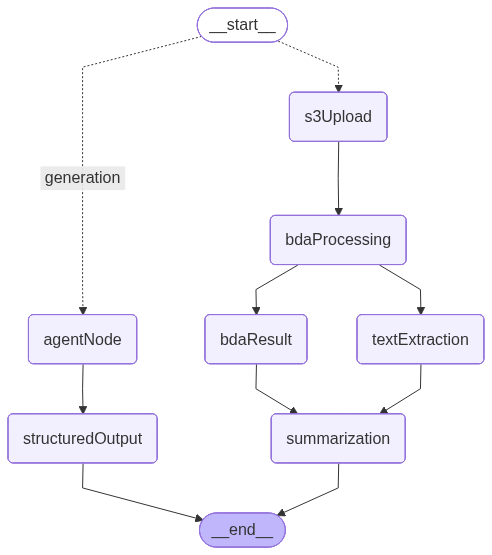

Agent Graph:


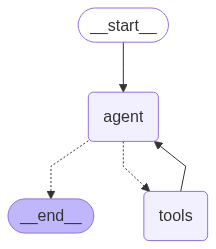

In [14]:
from IPython.display import Image as img, display
print("Graph:")
display(img(graph.get_graph().draw_mermaid_png()))

print("Agent Graph:")
display(img(agent.get_graph().draw_mermaid_png()))



In [ ]:
import json
session_id = "user-session-1"
config = {"configurable": {"thread_id": "1"}}

initial_state = {
    "document": None,
    "chat_history": [],
    "query": "",
    "response": "",
    "extracted_text": {},
    "bda_result":{},
    "s3Uri":{},
    "summary" : "",
    "question_list": [],

}

graph.update_state(config, values=initial_state, task_id=session_id)

def process_document(files):
    """Function to handle document upload and ingestion."""
    if files is None:
        return "Please upload a document first."
    file_bytes_list = {}
    # Read file bytes
    print(files)
    for file in files:
        file_bytes = ""
        with open(file.name, "rb") as f:
            file_bytes = f.read()
        file_bytes_list[os.path.basename(file.name)] = file_bytes

    current_state = graph.get_state(config)
    state_dict = dict(current_state.values)

    # Now you can modify it
    state_dict["document"] = file_bytes_list
    print(file_bytes_list.keys())
    # Invoke the graph with the updated dict
    text = graph.invoke(state_dict, config)
    # Persist updated state
    # graph.update_state(config, values=state_dict, task_id=session_id)
    print(text["question_list"])
    summary = text.get("summary", "No summary generated")
    questions = text.get("question_list", [])
    return summary, [[q] for q in questions]


# --- Chat Handler ---
def chat_interface(query, history):
    """Handle user chat messages with text + images using messages format."""
    if history is None:
        history = []

    # get & update state
    current_state = graph.get_state(config)
    state_dict = dict(current_state.values)
    state_dict["query"] = query

    # model response
    graph_state = graph.invoke(state_dict, config)
    ai_message = graph_state.get("response")
    # --- normalize to Python types ---
    if hasattr(ai_message, "model_dump"):       # pydantic v2
        ai_message = ai_message.model_dump()
    elif hasattr(ai_message, "dict"):           # pydantic v1
        ai_message = ai_message.dict()
    elif isinstance(ai_message, str):
        try:
            ai_message = json.loads(ai_message)  # stringified JSON
        except Exception:
            # fallback: just show raw text
            history = history + [{"role": "user", "content": query},
                                 {"role": "assistant", "content": ai_message}]
            return history

    # ensure list-of-dicts shape like your example
    if isinstance(ai_message, dict):
        ai_message = [ai_message]
    if not isinstance(ai_message, list) or not ai_message:
        # absolute fallback
        history = history + [{"role": "user", "content": query},
                             {"role": "assistant", "content": str(ai_message)}]
        return history

    payload = ai_message[0] or {}
    text_msg = payload.get("text_message")
    image_urls = payload.get("image_urls") or {}

    # --- build messages (messages format) ---
    # 1) append the user turn
    history = history + [{"role": "user", "content": query}]

    # 2) assistant text (if any)
    if text_msg:
        history.append({"role": "assistant", "content": str(text_msg)})

    for name, url in image_urls.items():
    # Add the name/label as a text message
        history.append({
            "role": "assistant",
            "content": f"**{name}**"   # markdown for bold name
        })
        # Add the image itself
        history.append({
            "role": "assistant",
            "content": gr.Image(value=str(url), show_label=False)
        })

    return history



current_state_snapshot = graph.get_state(config)
current_state = current_state_snapshot.values

with gr.Blocks(title="Document Processing Agent",css=".btn {height : 60px;}") as demo:
    gr.Markdown("# LangGraph Document Agent")
    with gr.Row():
        with gr.Column(scale=1):
            file_upload = gr.File(label="Upload Documents", file_count="multiple")
            process_button = gr.Button("Process Document", variant="primary")
            ingestion_output = gr.Textbox(label="Document Processing Status And Summary", value=current_state['summary'])

        with gr.Column(scale=2):
            chatbot = gr.Chatbot(label="Chat with Agent", type="messages")
            with gr.Row():
                user_input = gr.Textbox(scale=8, show_label=False, submit_btn=True, placeholder="")
                # send_button = gr.Button("Send", scale=2, variant="primary", elem_classes="btn")

            # Use Dataset instead of Examples
            suggested_examples = gr.Dataset(
                # visible=show_question,
                label="Suggested Questions",
                headers=["Suggested Questions"],
                components=[gr.Textbox(visible=False)],
                samples= [[q] for q in current_state['question_list']]
            )

    # --- Wire events ---
    def process_and_update(files):
        summary, questions = process_document(files)
        return summary, gr.update(samples=questions)

    process_button.click(
        fn=process_and_update,
        inputs=file_upload,
        outputs=[ingestion_output, suggested_examples]
    )

    # Clicking dataset row autofills textbox
    def load_example(row):
        return row[0]

    suggested_examples.select(fn=load_example, inputs=[suggested_examples], outputs=[user_input])

    # send_button.click(fn=chat_interface, inputs=[user_input, chatbot], outputs=chatbot)
    user_input.submit(fn=chat_interface, inputs=[user_input, chatbot], outputs=chatbot)

demo.launch()


{'document': None, 'chat_history': [], 'query': '', 'response': '', 'extracted_text': {}, 'bda_result': {}, 's3Uri': {}, 'summary': '', 'question_list': [], 'messages': []}
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


{'chat_history': [], 'query': 'Hey', 'response': '', 'document': None, 'extracted_text': {}, 'summary': '', 'question_list': [], 's3Uri': {}, 'bda_result': {}, 'messages': []}
---NODE: AGENT---
---NODE: STRUCTURED OUTPUT---
{'chat_history': [], 'query': 'Do you have any tool', 'response': [{'text_message': 'Hello! How can I help you today?', 'image_urls': {}}], 'document': None, 'extracted_text': {}, 'summary': '', 'question_list': [], 's3Uri': {}, 'bda_result': {}, 'messages': [HumanMessage(content='Hey', additional_kwargs={}, response_metadata={}, id='ab1898a5-6a4a-482e-b978-f61145ec7bc7'), AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--efe557d7-f587-4384-a5b7-8f79b982b227-0', usage_metadata={'input_tokens': 321, 'output_tokens': 63, 'total_tokens': 384, 'input_token_details': {'cache_r